# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [1]:
# Import necessary libraries 🔧
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load your uploaded file (path "/content/listings.csv.gz") 🔧
pd.read_csv("/content/listings.csv.gz")

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3176,https://www.airbnb.com/rooms/3176,20260626225638,2026-07-03,previous scrape,Fabulous Flat in great Location,This beautiful first floor apartment is situa...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,3718,...,4.70,4.92,4.61,First name and Last name: Nicolas Krotz <br/> ...,NaN,1,1,0,0,0.72
1,9991,https://www.airbnb.com/rooms/9991,20260626225638,2026-06-27,city scrape,Geourgeous flat - outstanding views,4 bedroom with very large windows and outstand...,NaN,https://a0.muscache.com/pictures/42799131/59c8...,33852,...,5.00,4.86,4.86,03/Z/RA/003410-18,NaN,1,1,0,0,0.05
2,14325,https://www.airbnb.com/rooms/14325,20260626225638,2026-07-03,previous scrape,Studio Apartment in Prenzlauer Berg,The apartment is located on the upper second f...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,55531,...,4.85,4.60,4.45,NaN,NaN,2,2,0,0,0.13
3,17904,https://www.airbnb.com/rooms/17904,20260626225638,2026-07-03,previous scrape,Beautiful Kreuzberg studio - 3 months minimum,- bright studio with scenic view on a river - ...,NaN,https://a0.muscache.com/pictures/d9a6f8be-54b9...,68997,...,4.92,4.88,4.65,NaN,NaN,1,1,0,0,1.49
4,20858,https://www.airbnb.com/rooms/20858,20260626225638,2026-06-27,city scrape,Designer Loft in Berlin Mitte,Bright and sunny condo with two balconies in a...,NaN,https://a0.muscache.com/pictures/108232/205b19...,71331,...,4.55,4.92,4.40,03/Z/RA/009767-24,NaN,1,1,0,0,0.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12771,1715902573765145718,https://www.airbnb.com/rooms/1715902573765145718,20260626225638,2026-06-27,city scrape,Arbio I Arabel Kingsize Apartment - Sleeps 8,Our kingsize apartments can accommodate up to...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,177619318,...,NaN,NaN,NaN,Legal entity name and Legal form: Arbio Akazia...,NaN,9,8,0,0,NaN
12772,1715903086163936513,https://www.airbnb.com/rooms/1715903086163936513,20260626225638,2026-06-27,city scrape,Arbio I Arabel 2 Bedroom Apartment - Sleeps 7,Our 2 bedroom apartments is 76sqm and can acco...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,177619318,...,NaN,NaN,NaN,Legal entity name and Legal form: Arbio Akazia...,NaN,9,8,0,0,NaN
12773,1715912656287408231,https://www.airbnb.com/rooms/1715912656287408231,20260626225638,2026-06-27,city scrape,Arbio I Arabel Suite - Sleeps 8,Our Suite Apartment can accommodate up to 8 pe...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,177619318,...,NaN,NaN,NaN,Legal entity name and Legal form: Arbio Akazia...,NaN,9,8,0,0,NaN
12774,1715912658233052227,https://www.airbnb.com/rooms/1715912658233052227,20260626225638,2026-06-27,city scrape,Arbio I Arabel King Suite - Sleeps 11,Our King Suite can accommodate up to 11 people...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,177619318,...,NaN,NaN,NaN,Legal entity name and Legal form: Arbio Akazia...,NaN,9,8,0,0,NaN


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

Columns with missing values and their percentages:
neighborhood_overview          100.000000
host_since                     100.000000
host_verifications             100.000000
host_total_listings_count      100.000000
host_thumbnail_url             100.000000
host_response_time             100.000000
host_acceptance_rate           100.000000
host_response_rate             100.000000
host_neighbourhood             100.000000
instant_bookable               100.000000
calendar_updated               100.000000
neighbourhood                  100.000000
bathrooms                       52.058547
beds                            48.951158
host_about                      46.008140
price_quote_total_price         33.930808
price                           33.930808
price_quote_price_per_night     33.930808
estimated_revenue_l365d         33.930808
price_quote_raw                 31.089543
price_quote_checkout_date       31.089543
price_quote_checkin_date        31.089543
license                  

/tmp/ipykernel_3022/946644688.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.index, y=missing_data.values, palette='coolwarm')


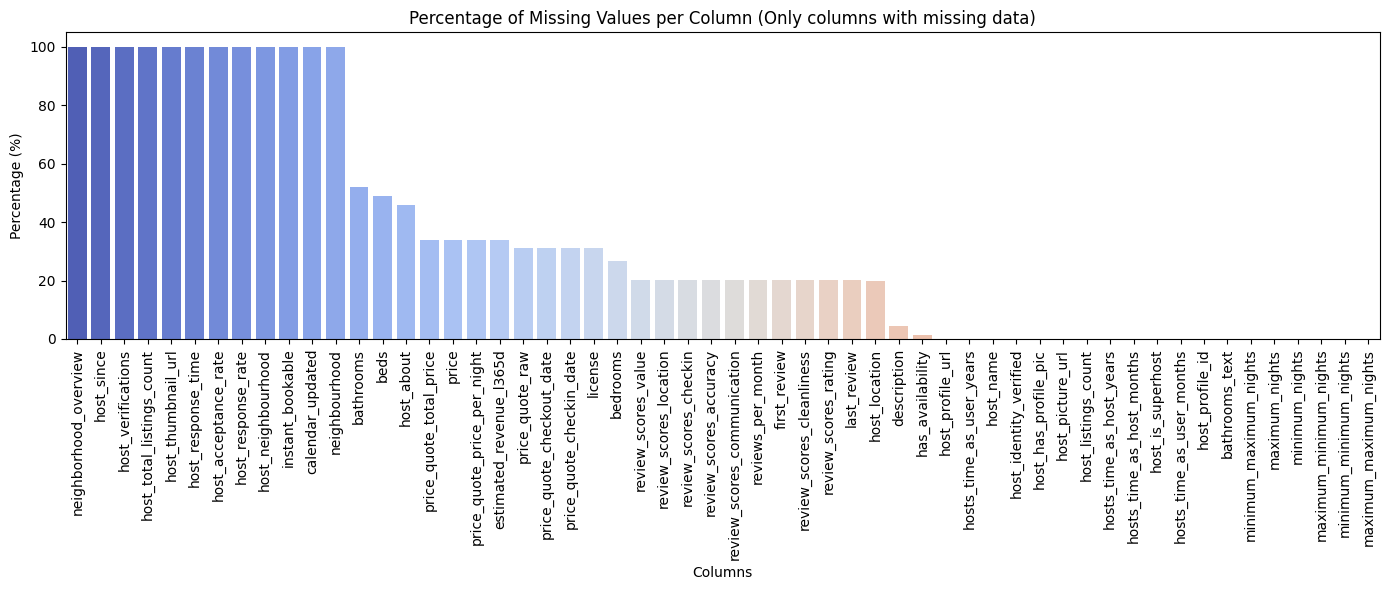

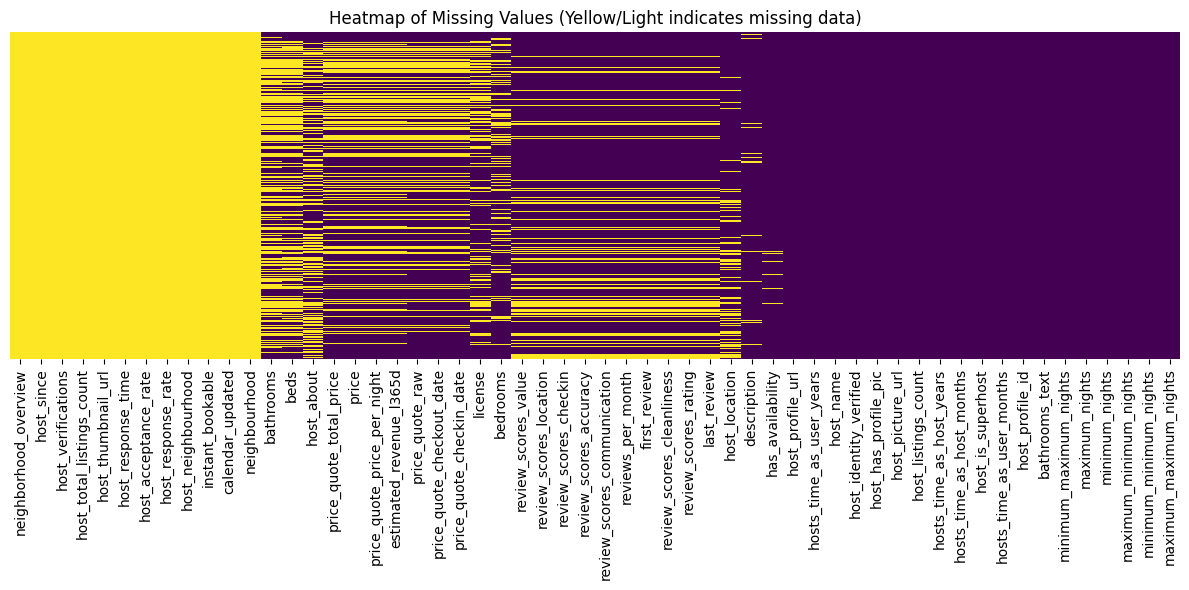

In [9]:
# Load your uploaded file
dataset = pd.read_csv("/content/listings.csv.gz")

# Count null values and calculate percentages
missing_counts = dataset.isnull().sum()
missing_percentages = (missing_counts / len(dataset)) * 100

# Filter columns that have any missing values
missing_data = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

# Print the summary
print("Columns with missing values and their percentages:")
print(missing_data)

# Visual 1: Bar chart showing the percentage of missing values per column
if not missing_data.empty:
    plt.figure(figsize=(14, 6))
    sns.barplot(x=missing_data.index, y=missing_data.values, palette='coolwarm')
    plt.xticks(rotation=90)
    plt.title('Percentage of Missing Values per Column (Only columns with missing data)')
    plt.ylabel('Percentage (%)')
    plt.xlabel('Columns')
    plt.tight_layout()
    plt.show()

    # Visual 2: Missingness Heatmap for columns with missing values
    plt.figure(figsize=(12, 6))
    sns.heatmap(dataset[missing_data.index].isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Heatmap of Missing Values (Yellow/Light indicates missing data)')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset!")

### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response: 🔧
1. Neighborhood_overview, host_since, and host_verifications.

2. Bathrooms, beds, and price are most likely to create business issues.

3. All of the columns that are 100% missing can safely be ignored or dropped.


## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [11]:

columns_to_drop = ['neighborhood_overview', 'host_since', 'host_verifications']
dataset = dataset.drop(columns=columns_to_drop, errors='ignore')

print("=== Dataset Info After Dropping Columns ===")
dataset.info()

display(dataset.head())

=== Dataset Info After Dropping Columns ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12776 entries, 0 to 12775
Data columns (total 87 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            12776 non-null  int64  
 1   listing_url                                   12776 non-null  object 
 2   scrape_id                                     12776 non-null  int64  
 3   last_scraped                                  12776 non-null  object 
 4   source                                        12776 non-null  object 
 5   name                                          12776 non-null  object 
 6   description                                   12217 non-null  object 
 7   picture_url                                   12776 non-null  object 
 8   host_id                                       12776 non-null  int64  
 9   host_url         

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3176,https://www.airbnb.com/rooms/3176,20260626225638,2026-07-03,previous scrape,Fabulous Flat in great Location,This beautiful first floor apartment is situa...,https://a0.muscache.com/pictures/hosting/Hosti...,3718,https://www.airbnb.com/users/show/3718,...,4.70,4.92,4.61,First name and Last name: Nicolas Krotz <br/> ...,NaN,1,1,0,0,0.72
1,9991,https://www.airbnb.com/rooms/9991,20260626225638,2026-06-27,city scrape,Geourgeous flat - outstanding views,4 bedroom with very large windows and outstand...,https://a0.muscache.com/pictures/42799131/59c8...,33852,https://www.airbnb.com/users/show/33852,...,5.00,4.86,4.86,03/Z/RA/003410-18,NaN,1,1,0,0,0.05
2,14325,https://www.airbnb.com/rooms/14325,20260626225638,2026-07-03,previous scrape,Studio Apartment in Prenzlauer Berg,The apartment is located on the upper second f...,https://a0.muscache.com/pictures/hosting/Hosti...,55531,https://www.airbnb.com/users/show/55531,...,4.85,4.60,4.45,NaN,NaN,2,2,0,0,0.13
3,17904,https://www.airbnb.com/rooms/17904,20260626225638,2026-07-03,previous scrape,Beautiful Kreuzberg studio - 3 months minimum,- bright studio with scenic view on a river - ...,https://a0.muscache.com/pictures/d9a6f8be-54b9...,68997,https://www.airbnb.com/users/show/68997,...,4.92,4.88,4.65,NaN,NaN,1,1,0,0,1.49
4,20858,https://www.airbnb.com/rooms/20858,20260626225638,2026-06-27,city scrape,Designer Loft in Berlin Mitte,Bright and sunny condo with two balconies in a...,https://a0.muscache.com/pictures/108232/205b19...,71331,https://www.airbnb.com/users/show/71331,...,4.55,4.92,4.40,03/Z/RA/009767-24,NaN,1,1,0,0,0.87


### Reflection:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response: 🔧
1. I dropped neighborhood_overview, host_since, and host_verification.

2. I dropped neighborhood_overview because it has 100% missing values and from a business perspective, it provides no context about the neighborhood. I dropped host_since because it was 100% empty and from a business perspective, we can't use it to evaluate the host's experience because there is no data. Finally, I dropped host_verifications because it is also 100% empty and from a business perspective, we can't verify the hosts, making it useless to keep.

3. If we left them in, it would waste storage and take up memory. Also, having blank columns could mislead analysts who could then waste time trying to fix it.



## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [30]:
dataset["host_about"] = dataset["host_about"].fillna("Unknown")

dataset["beds"] = dataset["beds"].fillna(dataset["beds"].median())

### Reflection:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

### ✍️ Your Response: 🔧
1. I cleaned hosts_about and beds.

2. I filled hosts_about missing values with "Unkown" because a listing can still work without the host's description. I filled missing bed values with the median number of beds because the median is less affected by outliers.

3. The risks are in having "Unkown" is that it can make the listing look incomplete and untrustworthy. The risk in filling beds with the median is that it creates made-up values.


## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

In [22]:
# Clean or adjust your dataset 🔧
print("Current data type of 'price':", dataset["price"].dtype)

# If 'price' is still text (object), clean and convert it
if dataset["price"].dtype == 'object':
    dataset["price"] = (
        dataset["price"]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

print("\nSummary statistics of 'price':")
print(dataset["price"].describe())

Current data type of 'price': float64

Summary statistics of 'price':
count     8441.000000
mean       160.729973
std        204.998115
min          2.720000
25%         72.000000
50%        130.670000
75%        207.000000
max      10025.000000
Name: price, dtype: float64


### Reflection: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?

### ✍️ Your Response: 🔧
1. I fixed the price column.

2. I removed the dollar signs and commas, then converted price to a number (float64)

3. This helps prepare the data for later use by making it usable in calculations and analysis.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

In [31]:
# Add code here 🔧
print("Exact duplicate rows:", dataset.duplicated().sum())
print("Duplicate IDs:", dataset["id"].duplicated().sum())

dataset = dataset.drop_duplicates()
dataset = dataset.drop_duplicates(subset="id")

Exact duplicate rows: 0
Duplicate IDs: 0


### Reflection:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response: 🔧 🔧
1. I did not find any duplicates.

2. Since there are no duplicates, I did not remove anything.

3. Duplicates are risky for Airbnb teams because it can make listings appear more available than it actually is.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [32]:
# export csv here 🔧
dataset.to_csv("cleaned_airbnb_data_6.csv", index=False)

## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts?
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information)
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. The section of the assignment that was most challenging for me is creating different charts and specifiying those difference values associated with it. The coding made it challenging.
2. I fixed the price column because it was stored as text with dollar signs and could not be used for calculations. Removing the dollar signs and converting it to a number made it usable for analyzing listing prices.
3. One way a business team might benefit from the cleaned version of this data by being able to accurately compare listing price and make better pricing decisions.
4. If I had more time, I would drop the other columns that had 100% missing values and look for outliers.
5. This relates to my customized learning outcomes I created in canvas because I cleaned real-world data in Python using a Jupyter notebook. I also connected the cleaning steps to a business goal.


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [34]:
!jupyter nbconvert --to html "assignment_06_data_cleaning.ipynb"

[NbConvertApp] Converting notebook assignment_06_data_cleaning.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 675781 bytes to assignment_06_data_cleaning.html
